In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import random
import pickle

from sklearn.cluster import SpectralClustering

from torchvision.datasets import MNIST

from dataset_builder import *
from clustering_utils import *
from Siamese_networks import *

In [5]:
train_loader, test_loader, mnist = prepare_mnist_data_triplets(subset_ratio = 0.01, train_ratio=0.75, batchsize=16)

Dataset preparato:
- Subset totale: 600 campioni
- Training set: 450 campioni
- Test set: 150 campioni
- Batch size: 16


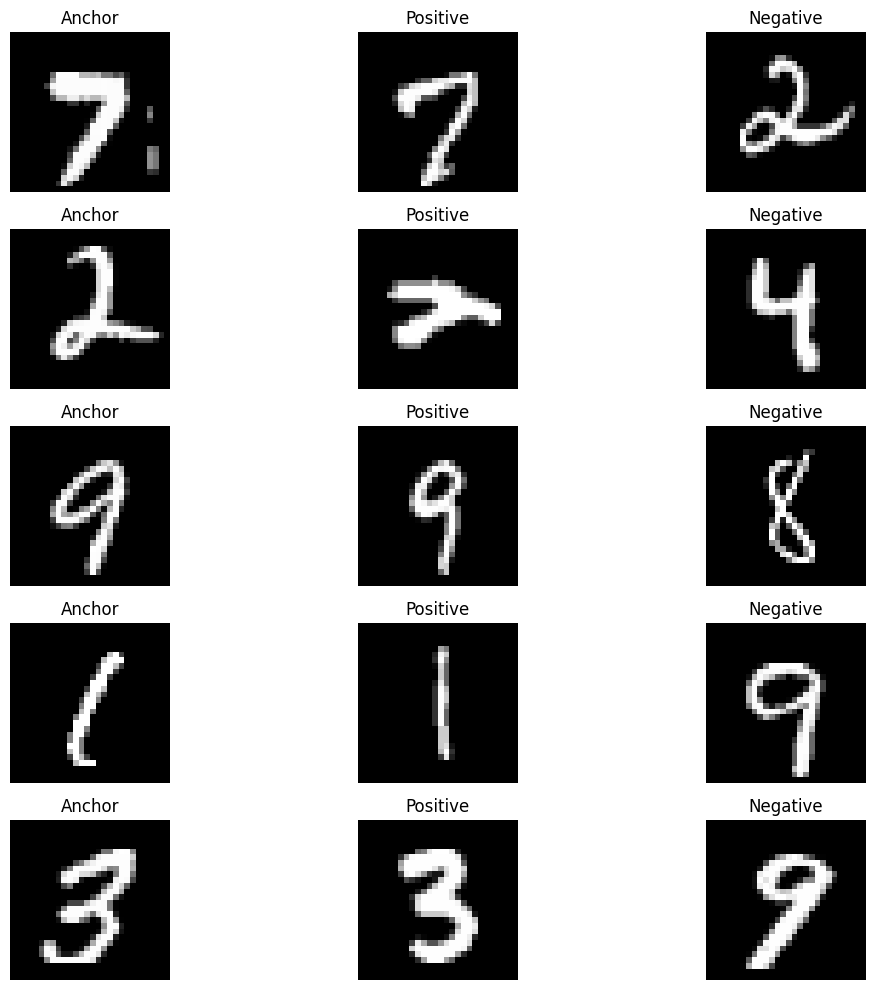

In [6]:
visualize_triplets(train_loader.dataset)

In [7]:
def train_model(model, train_loader, optimizer, criterion, epochs):

    counter = []
    loss_history = [] 
    iteration_number= 0

    for epoch in range(epochs):

        for i, (a, p, n) in enumerate(train_loader, 0):

            optimizer.zero_grad()
            output1, output2, output3 = model(a,p,n)
            loss_triplet = criterion(output1, output2, output3)
            loss_triplet.backward()
            optimizer.step()
            if i % 50 == 0 :
                print(f"Epoch {epoch} | batch {i} | Loss: {loss_triplet.item():.5f}\n")
                iteration_number += 10

                counter.append(iteration_number)
                loss_history.append(loss_triplet.item())
    
    return (counter, loss_history)

In [8]:
net = SiameseNetwork_Triplet(embedding_size = 64)
criterion = nn.TripletMarginLoss(margin=1.0, p=2)
optimizer = torch.optim.Adam(net.parameters(), lr = 0.0001)

counter, loss_history = train_model(net, train_loader, optimizer, criterion, epochs = 10)

Epoch 0 | batch 0 | Loss: 0.98880

Epoch 1 | batch 0 | Loss: 0.59495

Epoch 2 | batch 0 | Loss: 0.29873

Epoch 3 | batch 0 | Loss: 0.30224

Epoch 4 | batch 0 | Loss: 0.17248

Epoch 5 | batch 0 | Loss: 0.22353

Epoch 6 | batch 0 | Loss: 0.13051

Epoch 7 | batch 0 | Loss: 0.12405

Epoch 8 | batch 0 | Loss: 0.08651

Epoch 9 | batch 0 | Loss: 0.15628



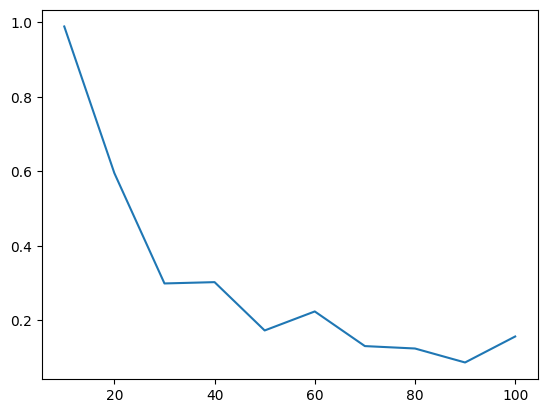

In [9]:
plt.plot(counter, loss_history)

In [10]:
def test_triplet_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for a, p, n in test_loader:
            output1, output2, output3 = model(a, p, n)
            
            distances_ap = F.pairwise_distance(output1, output2)
            distances_an = F.pairwise_distance(output1, output3)
            correct += (distances_ap < distances_an).sum().item()
            total += len(a)

    accuracy = correct / total
    print(f'Test Accuracy: {accuracy * 100:.2f}%')

In [11]:
test_triplet_model(net, test_loader)

Test Accuracy: 92.00%


---

In [12]:
embedding_set, labels = create_embedding_dataset(net, MNIST_data_loader())

Processato batch 0/40


In [ ]:
n_clusters = 10  # ad esempio per MNIST

clustering = SpectralClustering(
    n_clusters=n_clusters,
    affinity='nearest_neighbors',  # usa k-NN per costruire il grafo di similarità
    assign_labels='kmeans',
    random_state=0
)

cluster_labels = clustering.fit_predict(embedding_set)

Applicando t-SNE per visualizzazione...


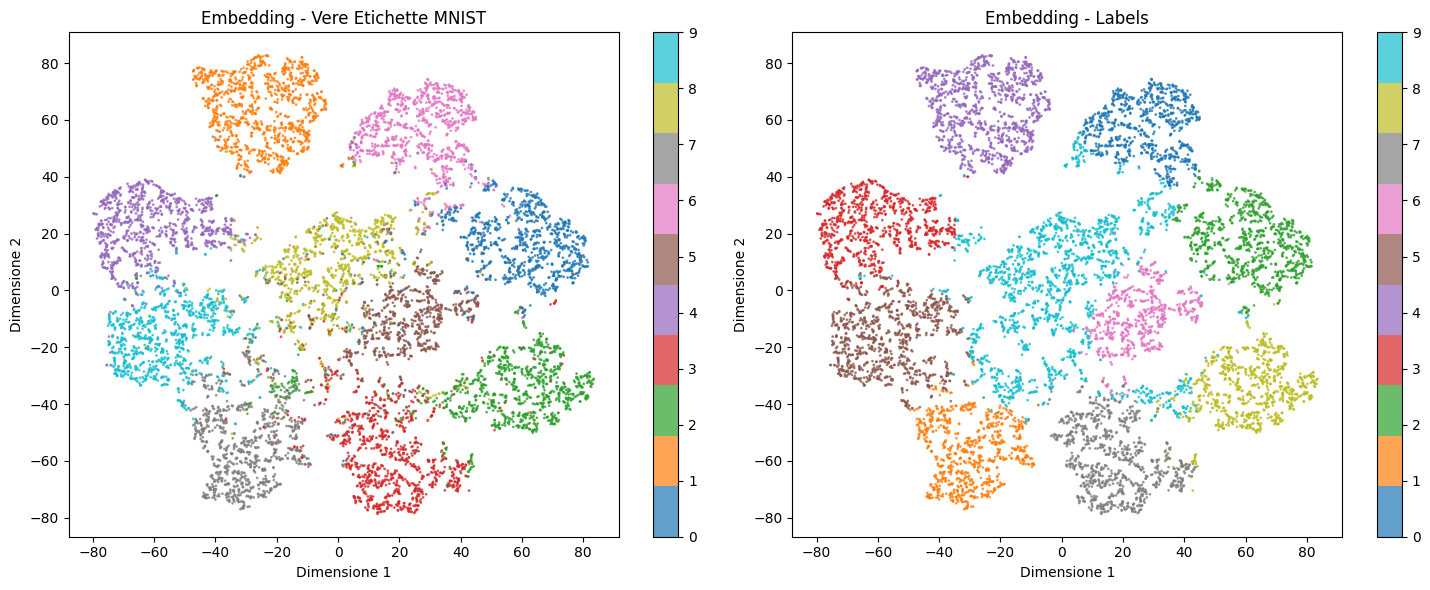

In [14]:
visualize_embeddings(embeddings = embedding_set, embedding_size=64, true_labels=labels, cluster_labels = cluster_labels)

In [15]:
# salvataggio modello
with open("models/SN_data1%_Triplets.pkl", "wb") as f:
    pickle.dump(net, f)